In [1]:
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

solar_config_path = Path('config/arctic_cloud_experiment_solar.yaml')
thermal_config_path = Path('config/arctic_cloud_experiment_thermal.yaml')


This is an advanded example showing how to do sensitivity studies on cloud parameters , caluclating the cloud radiative effect in a closed libradtran setup. We caluclate the net irradiance for the solar (300-3000nm) and thermal (3000-100000nm) bands, for cloud free and cloudy conditions. 


| Surface type        | Shortwave albedo α (broadband) | Longwave emissivity ε (8–13 µm) | Notes / typical use |
|---------------------|--------------------------------|----------------------------------|---------------------|
| Open water          | 0.05 – 0.10                    | 0.985 – 0.990                    | Low SW reflectance; near-blackbody in TIR |
| Thin ice (nilas / young ice) | 0.15 – 0.40            | 0.970 – 0.985                    | Strong thickness dependence; key for leads |
| Snow-covered sea ice| 0.75 – 0.90                    | 0.980 – 0.995                    | Very high SW albedo; excellent LW emitter |


In [2]:
albedos_sw = np.arange(0, 1, 0.1)
albedos_lw = np.arange(0, 1, 0.1) * 0 # set them all zero, it's an okayapproximation 
#albedos_lw = [1 - 0.987, 1 - 0.985, 1 - 0.98, 1 - 0.991] # 1 - emissivity ... naja

# libradtran handles emissivity = 1 - albedo ; 

In [3]:
# Define a simple profile
# z: 2km to 1km (descending required by uvspec)
# 

# lwcs = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200,]
# reffs = [10]
# Arctic stratus parameter space (libRadtran units!)

cbh   = [0.3]        # km
cth   = [1.0]        # km

lwps = np.array([10, 15, 20, 30, 50, 100, 200, 400, 800])
lwcs = lwps / 700
reffs = [15]                    # µm

surface_temperatures = np.linspace(273.15, 273.15 - 30, len(albedos_sw))
cbh = [0.3] * len(lwcs)
cth = [1] * len(lwcs)
# add a low-level cloud with varying LWC
times = pd.date_range("2024-03-01 12:00", periods=20, freq="7d")
lats = np.arange(80, 60, -1)
print(lats)
lon = [0] * len(times)
altitudes = [0, 1, 10, 100]
#szas = np.arange(30, 90, 5)

ds = xr.Dataset(
    coords={
        "time": times, 
        "latitude": (("time",), lats), 
        "longitude": (("time",), lon),
        "altitude": (("altitude",), altitudes)
    },
    data_vars={
        "lwc": (("lwc",), lwcs),
        "reff": (("reff",), reffs),
        "cth": (("lwc",), cth),
        "cbh": (("lwc",), cbh),
        "surface_temperature": (("albedo",), surface_temperatures),
        "albedo_sw": (("albedo",), albedos_sw),
        "albedo_lw": (("albedo",), albedos_lw),
    }
)

ds_sim_no_cloud_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    #surface_type_var='surface_type',
    save_to_file=True, 
    return_dataset=True,
)

ds_sim_no_cloud_thermal = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_thermal.yaml',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_lw',
    #surface_type_var='surface_type',
    save_to_file=True, 
    return_dataset=True,
)

ds_sim_cloudy_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    #surface_type_var='surface_type',
    save_to_file=True, 
    return_dataset=True,
)

ds_sim_cloudy_thermal = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_thermal.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_lw',
    #surface_type_var='surface_type',
    save_to_file=True, 
    return_dataset=True,
)   

[80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61]


Running simulations: 100%|██████████| 1800/1800 [07:54<00:00,  3.79sim/s, Success=1800, Total=1800]
2025-12-13 22:12:20,518 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
Running simulations: 100%|██████████| 1800/1800 [01:44<00:00, 17.18sim/s, Success=1800, Total=1800]
2025-12-13 22:14:06,054 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
Running simulations: 100%|██████████| 1800/1800 [09:52<00:00,  3.04sim/s, Success=1800, Total=1800]
2025-12-13 22:23:59,579 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
Running simulations: 100%|██████████| 1800/1800 [02:11<00:00, 13.73sim/s, Success=1800, Total=1800]


In [4]:
ds_sim_no_cloud_solar_normed = ds_sim_no_cloud_solar / 1000
ds_sim_cloudy_solar_normed = ds_sim_cloudy_solar / 1000
ds_cre_solar = ds_sim_cloudy_solar_normed - ds_sim_no_cloud_solar_normed
ds_cre_thermal = ds_sim_cloudy_thermal - ds_sim_no_cloud_thermal
ds_cre_total = ds_cre_solar + ds_cre_thermal
ds_cre_total = ds_cre_total.squeeze()

ds_cre_total = ds_cre_total.assign_coords(
    {'albedo' : albedos_sw}
)

In [5]:

ds_cre_total['enet_zero'] = (('lwc', 'albedo', 'time'), np.isclose(ds_cre_total.enet.isel(altitude=0), 0, atol=.5))    

In [38]:
import pandas as pd
import pvlib

def calculate_solar_zenith_angle(time, latitude, longitude):
    solpos = pvlib.solarposition.get_solarposition(times, latitude, longitude)
    return solpos['zenith']
sza = calculate_solar_zenith_angle(ds.time.values, ds.latitude.values, ds.longitude.values)
sza

2024-03-01 12:00:00    87.308757
2024-03-08 12:00:00    83.600046
2024-03-15 12:00:00    79.841690
2024-03-22 12:00:00    76.072131
2024-03-29 12:00:00    72.326330
2024-04-05 12:00:00    68.636291
2024-04-12 12:00:00    65.035708
2024-04-19 12:00:00    61.559141
2024-04-26 12:00:00    58.238263
2024-05-03 12:00:00    55.101745
2024-05-10 12:00:00    52.179414
2024-05-17 12:00:00    49.501237
2024-05-24 12:00:00    47.093743
2024-05-31 12:00:00    44.978874
2024-06-07 12:00:00    43.176652
2024-06-14 12:00:00    41.702779
2024-06-21 12:00:00    40.565954
2024-06-28 12:00:00    39.767156
2024-07-05 12:00:00    39.302199
2024-07-12 12:00:00    39.159366
Freq: 7D, Name: zenith, dtype: float64

In [7]:
ds_cre_total['sza'] = ('time', sza)
ds_cre_sza = ds_cre_total.groupby_bins('sza', [30, 40, 50, 60, 70, 80, 90, 100]).mean()

Text(0, 0.5, 'Surface albedo ')

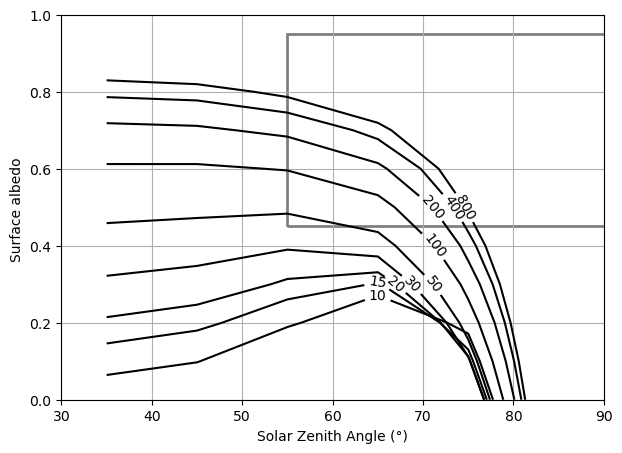

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = plt.cm.inferno(np.linspace(0, 1, len(ds_cre_total.lwc)))

for i, lwc in enumerate(ds_cre_total.lwc.values):
        
    cs = ds_cre_sza.isel(altitude=0).sel(lwc=lwc).enet.plot.contour(x='sza_bins', colors='k', levels=[0])
    # add lwc to complete the label 
    cs.clabel(fmt=f'{lwps[i]}', colors='k')

# show SHEBA region
from matplotlib.patches import Rectangle

ax.add_patch(Rectangle((55, .45), 50, .5, alpha=0.5, edgecolor='k', linewidth=2, fill=False))

ax.set_xlim(30, 90)
ax.set_ylim(0, 1)
ax.set_title('')
ax.grid()
ax.set_xlabel('Solar Zenith Angle (°)')
ax.set_ylabel('Surface albedo ')


In [37]:
# Define a simple profile
# z: 2km to 1km (descending required by uvspec)
# 

# lwcs = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200,]
# reffs = [10]
# Arctic stratus parameter space (libRadtran units!)

cbh   = [0.3]        # km
cth   = [1.0]        # km

lwps = np.array([10, 15, 20, 30, 50, 100, 200, 400, 800])
iwcs = lwps / 700
reffs = [15]                    # µm

surface_temperatures = np.linspace(273.15, 273.15 - 30, len(albedos_sw))
cbh = [0.3] * len(iwcs)
cth = [1] * len(iwcs)
# add a low-level cloud with varying LWC
times = pd.date_range("2024-03-01 12:00", periods=20, freq="7d")
lats = np.arange(80, 60, -1)
print(lats)
lon = [0] * len(times)
altitudes = [0, 1, 10, 100]
#szas = np.arange(30, 90, 5)

ds = xr.Dataset(
    coords={
        "time": times, 
        "latitude": (("time",), lats), 
        "longitude": (("time",), lon),
        "altitude": (("altitude",), altitudes)
    },
    data_vars={
        "iwc": (("iwc",), lwcs),
        "reff": (("reff",), reffs),
        "cth": (("iwc",), cth),
        "cbh": (("iwc",), cbh),
        "surface_temperature": (("albedo",), surface_temperatures),
        "albedo_sw": (("albedo",), albedos_sw),
        "albedo_lw": (("albedo",), albedos_lw),
    }
)


ds_sim_cloudy_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    cloud_ic_var='iwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    #surface_type_var='surface_type',
    save_to_file=True, 
    return_dataset=True,
)

2025-12-13 22:46:26,742 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig


[80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61]


Running simulations: 100%|██████████| 1800/1800 [09:46<00:00,  3.07sim/s, Success=1800, Total=1800]


Now to the cool part: We show what effect the cloud has on the surface net radiation, dependiing on the surface type.